# 1. Định nghĩa vấn đề

Bộ dữ liệu "Animal Condition Classification Dataset" (Phân loại Tình trạng Động vật) trình bày một thách thức dữ liệu độc đáo và phức tạp trong lĩnh vực đánh giá sức khỏe động vật. Với sự đa dạng các loài động vật, từ chim đến thú, bộ dữ liệu này cho phép phát triển các mô hình dự đoán để xác định xem tình trạng của một con vật có nguy hiểm hay không dựa trên năm triệu chứng riêng biệt.

Mô tả tệp data.csv:

    + AnimalName: Tên động vật (Chứa loại động vật. Ví dụ: chó, mèo, v.v.).

    + symptoms1-5: Triệu chứng 1-5 (Chứa các thông tin về triệu chứng bệnh).

    + Dangerous: Nguy hiểm (Chứa thông tin xác định tình trạng bệnh có nguy hiểm hay không).

## 2. Chuẩn bị vấn đề

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC

In [10]:
df=pd.read_csv('data.csv')

## 3. Thống kê mô tả

## 3.1 Hiển thị một số thông tin về dữ liệu

+ Số dòng, số cột của dữ liệu
+ Kiểu dữ liệu của từng cột
+ 5 dòng đầu của bảng dữ liệu
+ Thông tin chung về dữ liệu

In [11]:
# shape
print(f'+ Shape: {df.shape}')
# types
print(f'+ Data Types: \n{df.dtypes}')

+ Shape: (871, 7)
+ Data Types: 
AnimalName    object
symptoms1     object
symptoms2     object
symptoms3     object
symptoms4     object
symptoms5     object
Dangerous     object
dtype: object


In [12]:
print("Dữ liệu đầu vào:")
df.head()

Dữ liệu đầu vào:


,AnimalName,symptoms1,symptoms2,symptoms3,symptoms4,symptoms5,Dangerous
0,Dog,Fever,Diarrhea,Vomiting,Weight loss,Dehydration,Yes
1,Dog,Fever,Diarrhea,Coughing,Tiredness,Pains,Yes
2,Dog,Fever,Diarrhea,Coughing,Vomiting,Anorexia,Yes
3,Dog,Fever,Difficulty breathing,Coughing,Lethargy,Sneezing,Yes
4,Dog,Fever,Diarrhea,Coughing,Lethargy,Blue Eye,Yes


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 871 entries, 0 to 870
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   AnimalName  871 non-null    object
 1   symptoms1   871 non-null    object
 2   symptoms2   871 non-null    object
 3   symptoms3   871 non-null    object
 4   symptoms4   871 non-null    object
 5   symptoms5   871 non-null    object
 6   Dangerous   869 non-null    object
dtypes: object(7)
memory usage: 47.8+ KB


## 3.2 Các tính chất thống kê trên dữ liệu số

In [14]:
df.describe()

,AnimalName,symptoms1,symptoms2,symptoms3,symptoms4,symptoms5,Dangerous
count,871,871,871,871,871,871,869
unique,46,232,230,229,217,203,2
top,Buffaloes,Fever,Diarrhea,Coughing,Weight loss,Pains,Yes
freq,129,257,119,95,117,99,849


# 4. Chuẩn bị dữ liệu

## 4.1 Giá trị thiếu

In [15]:
print("Số lượng giá trị missing ở từng cột:")
df.isnull().sum()

Số lượng giá trị missing ở từng cột:


AnimalName    0
symptoms1     0
symptoms2     0
symptoms3     0
symptoms4     0
symptoms5     0
Dangerous     2
dtype: int64

In [16]:
# Loại bỏ giá trị thiếu
df.dropna(inplace=True)

## 4.2 Giá trị trùng

In [17]:
# Loại bỏ giá trị trùng
df[df.duplicated()]

,AnimalName,symptoms1,symptoms2,symptoms3,symptoms4,symptoms5,Dangerous
772,Tiger,Fetopelvic dispropotion,Uteria inertia,Malpresentation,Death,Pains,Yes
773,Tiger,Fetopelvic dispropotion,Uteria inertia,Malpresentation,Death,Pains,Yes
774,Tiger,Fetopelvic dispropotion,Uteria inertia,Malpresentation,Death,Pains,Yes
775,Tiger,Fetopelvic dispropotion,Uteria inertia,Malpresentation,Death,Pains,Yes
776,Tiger,Fetopelvic dispropotion,Uteria inertia,Malpresentation,Death,Pains,Yes
777,Tiger,Fetopelvic dispropotion,Uteria inertia,Malpresentation,Death,Pains,Yes
778,Tiger,Fetopelvic dispropotion,Uteria inertia,Malpresentation,Death,Pains,Yes
779,Tiger,Fetopelvic dispropotion,Uteria inertia,Malpresentation,Death,Pains,Yes
780,Tiger,Fetopelvic dispropotion,Uteria inertia,Malpresentation,Death,Pains,Yes
781,Tiger,Fetopelvic dispropotion,Uteria inertia,Malpresentation,Death,Pains,Yes


In [18]:
df.drop_duplicates(inplace=True)

## 4.3 Chuẩn hóa dữ liệu dạng chuỗi

In [19]:
df.AnimalName.value_counts()

AnimalName
Buffaloes            128
Sheep                109
Pig                   63
Fowl                  62
Elephant              59
Duck                  56
Birds                 37
cat                   36
Dog                   34
Donkey                33
Monkey                28
Goat                  26
Deer                  26
Cattle                21
Hamster               18
Lion                  16
Rabbit                11
Horse                 10
Chicken                9
Fox                    7
Tiger                  6
Other Birds            6
horse                  5
chicken                4
Turtle                 4
cow                    3
Pigs                   3
Goats                  2
donkey                 2
cattle                 1
Fox                    1
mammal                 1
snake                  1
duck                   1
mules                  1
Elk                    1
Wapiti                 1
Mule deer              1
Reindeer               1
White-tailed d

In [20]:
#Tránh trùng lặp dạng "lion", "Lion", "LION"
df['AnimalName']=df.AnimalName.str.capitalize()

In [21]:
df.AnimalName.value_counts()

AnimalName
Buffaloes            128
Sheep                109
Pig                   63
Fowl                  62
Elephant              59
Duck                  57
Birds                 37
Cat                   36
Donkey                35
Dog                   34
Monkey                28
Deer                  26
Goat                  26
Cattle                22
Hamster               18
Lion                  16
Horse                 15
Chicken               13
Rabbit                11
Fox                    7
Tiger                  6
Other birds            6
Turtle                 4
Pigs                   3
Cow                    3
Goats                  2
Mammal                 1
Fox                    1
Snake                  1
Mules                  1
Elk                    1
Wapiti                 1
Mule deer              1
Reindeer               1
White-tailed deer      1
Sika deer              1
Black-tailed deer      1
Moos                   1
Dogs                   1
Wolves        

## 4.4 Gom nhóm động vật

In [22]:
#Gom nhóm động vật
df['AnimalName'] = df['AnimalName'].replace({
    'Black-tailed deer':'Deer', 'White-tailed deer':'Deer', 'Mule deer':'Deer',
    'Sika deer':'Deer', 'Reindeer':'Deer', 'Elk':'Deer', 'Wapiti':'Deer',
    'Mules':'Horse', 'Other birds': 'Birds', 'Pigs':'Pig', 'Dogs': 'Dog', 
    'Fox ':'Fox', 'Goats': 'Goat'
})

In [23]:
df.AnimalName.value_counts()

AnimalName
Buffaloes    128
Sheep        109
Pig           66
Fowl          62
Elephant      59
Duck          57
Birds         43
Cat           36
Donkey        35
Dog           35
Deer          33
Monkey        28
Goat          28
Cattle        22
Hamster       18
Lion          16
Horse         16
Chicken       13
Rabbit        11
Fox            8
Tiger          6
Turtle         4
Cow            3
Mammal         1
Moos           1
Snake          1
Wolves         1
Hyaenas        1
Name: count, dtype: int64

## 4.5 Mã hóa nhãn

In [24]:
le=LabelEncoder()

In [25]:
for col in df.columns:
    if df[col].dtype=='object':
        df[col]=le.fit_transform(df[col])

## 4.6 Tách đặc trưng (X) và nhãn (y)

In [26]:
# Tách đặc trưng và nhãn (Condition là target multiclass)
X = df.drop('Dangerous', axis=1)
y = df['Dangerous']

In [27]:
#X = df.iloc[:, :-1]
#y = df.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25,random_state=90)

In [28]:
print("Kích thước tập train:", X_train.shape)
print("Kích thước tập test:", X_test.shape)

Kích thước tập train: (630, 6)
Kích thước tập test: (211, 6)


In [29]:
print("\nPhân bố lớp trong tập train:")
print(y_train.value_counts())


Phân bố lớp trong tập train:
Dangerous
1    615
0     15
Name: count, dtype: int64


## 4.7 Chuẩn hóa dữ liệu (Scaling)

In [30]:
# SVM rất nhạy với thang đo của các đặc trưng → phải chuẩn hóa
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Đã chuẩn hóa dữ liệu thành công!")

Đã chuẩn hóa dữ liệu thành công!


# 5. Huấn luyện SVM

In [31]:
clf = svm.SVC(kernel='rbf', C=1.0, random_state=101)
clf.fit(X_train_scaled, y_train)

# Đánh giá độ chính xác
train_acc = clf.score(X_train_scaled, y_train)
test_acc = clf.score(X_test_scaled, y_test)

print('Training accuracy: {:.4f}'.format(train_acc))
print('Test accuracy: {:.4f}'.format(test_acc))

Training accuracy: 0.9762
Test accuracy: 0.9763


## 5.2 Tìm mô hình tốt nhất

In [32]:
# Danh sách các kernel cần thử nghiệm
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

best_svm = None
best_val_acc = -1
best_kernel = None

print("\n--- Đang tìm kiếm Kernel tối ưu ---")
for kernel in kernels:
    # Khởi tạo và huấn luyện mô hình
    # probability=True để mô hình tính toán được xác suất (nếu cần vẽ ROC sau này)
    clf = svm.SVC(kernel=kernel, probability=True, random_state=42)
    clf.fit(X_train_scaled, y_train)
    
    # Đánh giá độ chính xác trên tập Test
    acc = clf.score(X_test_scaled, y_test)
    print(f"Kernel: {kernel:10s} -> Accuracy: {acc:.4f}")
    
    # Lưu lại kết quả tốt nhất
    if acc > best_val_acc:
        best_val_acc = acc
        best_svm = clf
        best_kernel = kernel

print(f"\n=> Kernel tốt nhất là: '{best_kernel}' với độ chính xác: {best_val_acc:.4f}")


--- Đang tìm kiếm Kernel tối ưu ---
Kernel: linear     -> Accuracy: 0.9763
Kernel: poly       -> Accuracy: 0.9763
Kernel: rbf        -> Accuracy: 0.9763
Kernel: sigmoid    -> Accuracy: 0.9763

=> Kernel tốt nhất là: 'linear' với độ chính xác: 0.9763


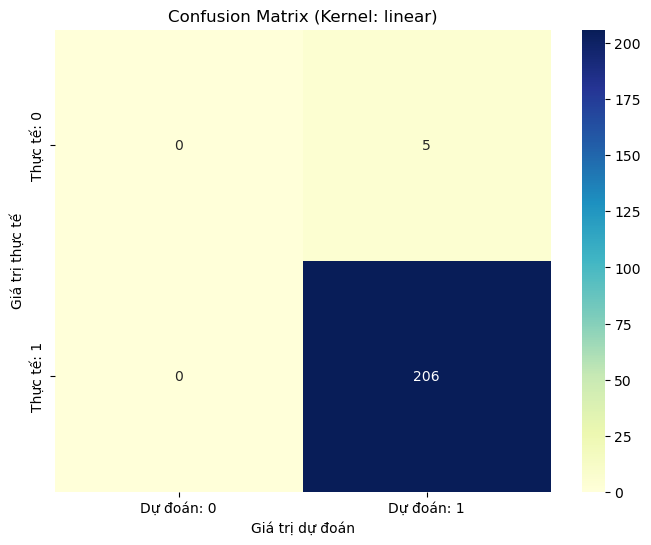


--- Báo cáo phân loại (Classification Report) ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.98      1.00      0.99       206

    accuracy                           0.98       211
   macro avg       0.49      0.50      0.49       211
weighted avg       0.95      0.98      0.96       211



D:\code\anaconda\ana\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\code\anaconda\ana\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\code\anaconda\ana\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [34]:
# Dự đoán lại bằng mô hình tốt nhất đã lưu
y_pred = best_svm.predict(X_test_scaled)

# 1. Vẽ Confusion Matrix (Heatmap)
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Thực tế: 0', 'Thực tế: 1'], columns=['Dự đoán: 0', 'Dự đoán: 1'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='YlGnBu')
plt.title(f'Confusion Matrix (Kernel: {best_kernel})')
plt.ylabel('Giá trị thực tế')
plt.xlabel('Giá trị dự đoán')
plt.show()

# 2. Báo cáo phân loại chi tiết
print("\n--- Báo cáo phân loại (Classification Report) ---")
print(classification_report(y_test, y_pred))